# Visualization 04 Subscription Churn

Converted from `visualizations/04_subscription_churn.py`.


In [1]:
# Notebook bootstrap generated from visualizations/04_subscription_churn.py
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data_cleaning' else Path.cwd()
VISUALIZATIONS_DIR = PROJECT_ROOT / 'visualizations'
if str(VISUALIZATIONS_DIR) not in sys.path:
    sys.path.insert(0, str(VISUALIZATIONS_DIR))
os.chdir(VISUALIZATIONS_DIR)
__file__ = str(VISUALIZATIONS_DIR / '04_subscription_churn.py')

from IPython.display import display

def inline_save(fig, name):
    display(fig)
    try:
        import matplotlib.pyplot as plt
        plt.close(fig)
    except Exception:
        pass
    print(f"  Displayed inline: {name}")
    return None


In [2]:
"""
04_subscription_churn.py
Charts: subscriber vs one-time LTV, subscription churn by cycle,
        cancellation reasons, subscriber tenure distribution
"""
import sys
from pathlib import Path
sys.path.insert(0, str(Path(__file__).parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from style import save, TEAL, NAVY, ORANGE, RED, SLATE, GOLD, LIGHT_BG, LILAC

# Notebook override: display charts inline instead of writing PNG files.
save = inline_save



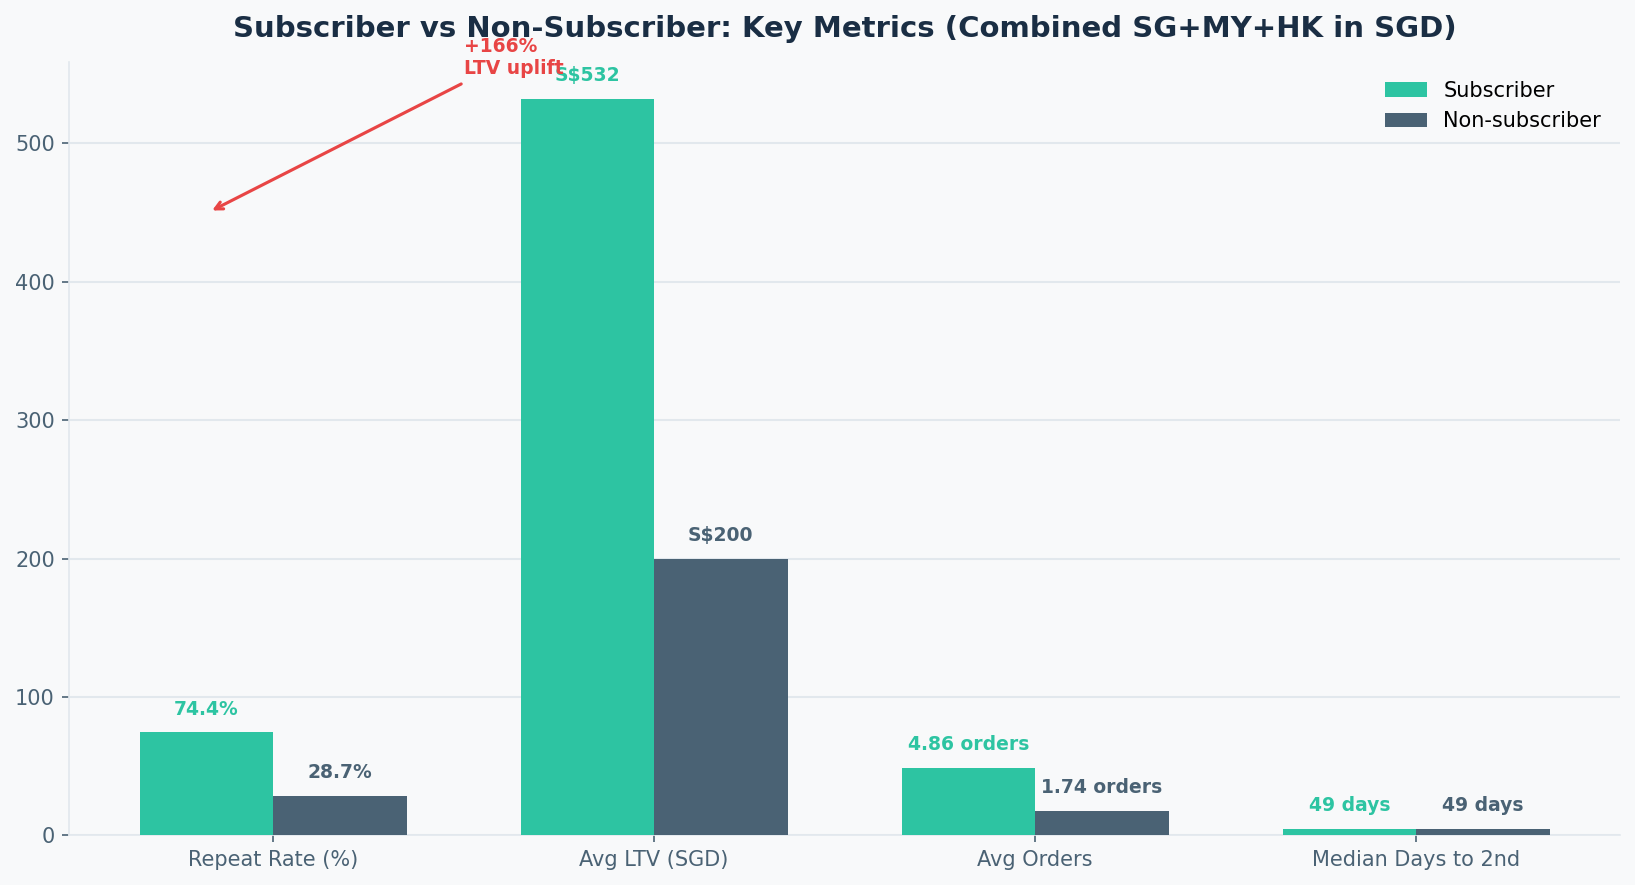

  Displayed inline: 04a_subscriber_vs_onetime


In [3]:
# ── Chart 1: Subscriber vs one-time LTV metrics ────────────────────────────────
metrics    = ["Repeat Rate","Avg LTV","Avg Orders\n(×10 SGD scale)","Median Days\nto 2nd Order (÷10)"]
sub_vals   = [74.4, 532, 48.6, 4.8]
nonsub_vals= [28.7, 200, 17.4, 4.9]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(4); w = 0.35
b1 = ax.bar(x-w/2, sub_vals,   width=w, color=TEAL, label="Subscriber",     zorder=3)
b2 = ax.bar(x+w/2, nonsub_vals,width=w, color=SLATE, label="Non-subscriber", zorder=3)
ax.set_xticks(x); ax.set_xticklabels(["Repeat Rate (%)", "Avg LTV (SGD)", "Avg Orders", "Median Days to 2nd"], fontsize=10)
ax.set_title("Subscriber vs Non-Subscriber: Key Metrics (Combined SG+MY+HK in SGD)")
ax.legend()

labels_sub   = ["74.4%", "S$532", "4.86 orders", "49 days"]
labels_non   = ["28.7%", "S$200", "1.74 orders", "49 days"]
for bar, lbl in zip(b1, labels_sub):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            lbl, ha="center", va="bottom", fontsize=9, color=TEAL, fontweight="bold")
for bar, lbl in zip(b2, labels_non):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            lbl, ha="center", va="bottom", fontsize=9, color=SLATE, fontweight="bold")

ax.annotate("+166%\nLTV uplift", xy=(-0.17, 450), xytext=(0.5, 550),
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.5), fontsize=9, color=RED, fontweight="bold")
fig.tight_layout()
save(fig, "04a_subscriber_vs_onetime")



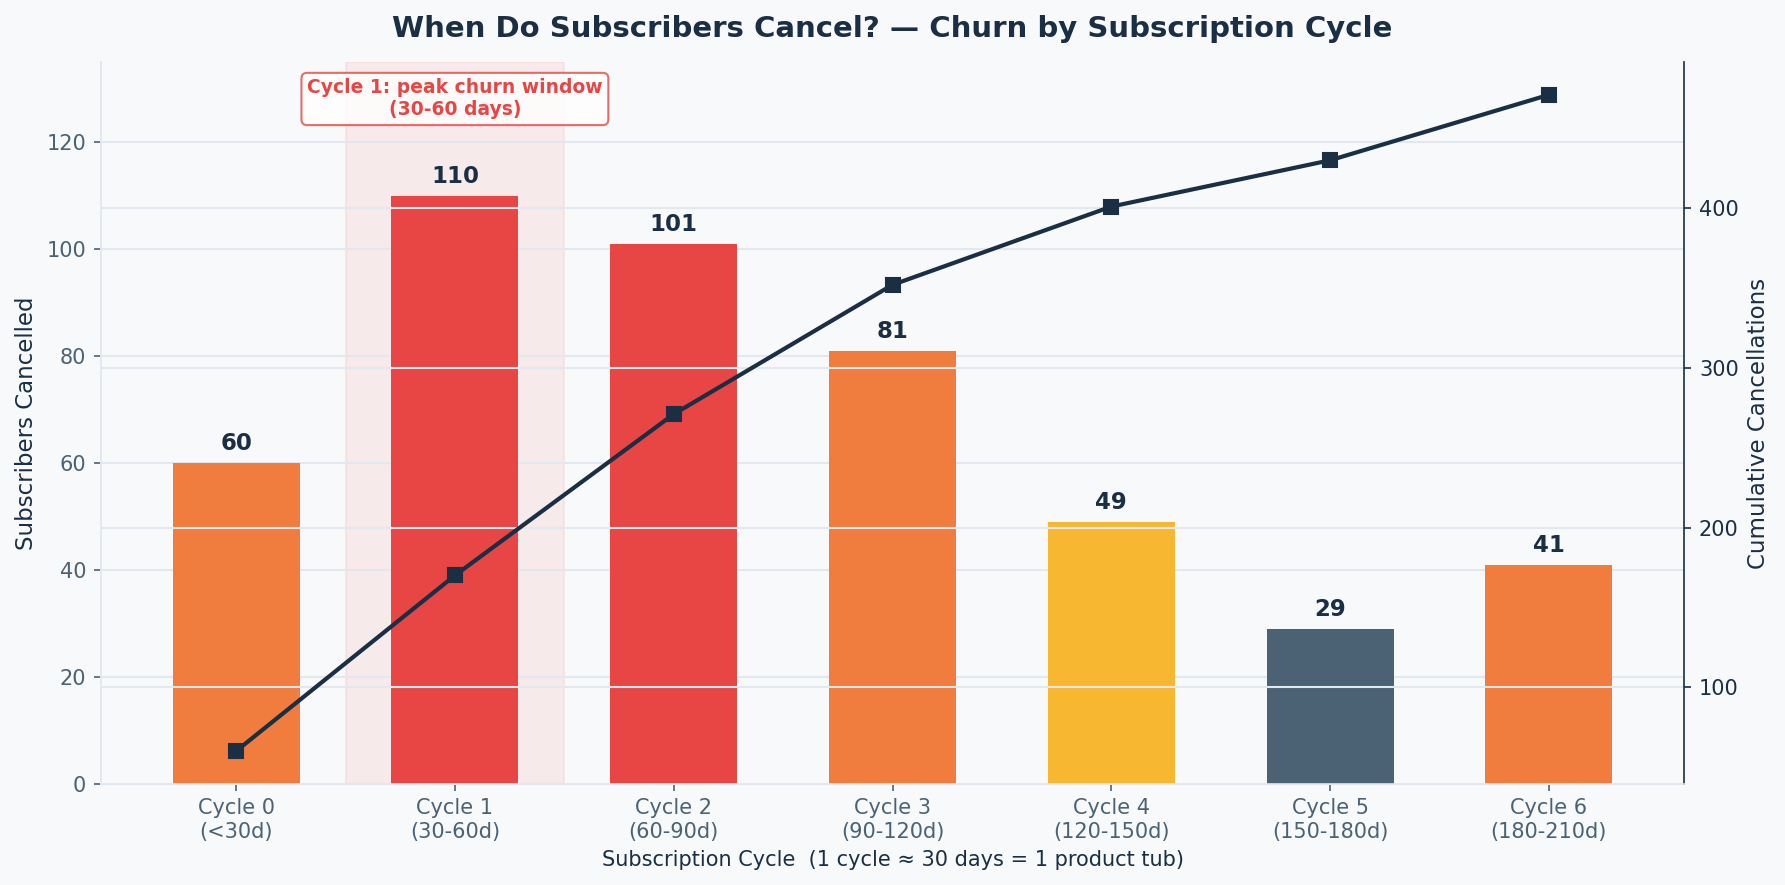

  Displayed inline: 04b_churn_by_cycle


In [4]:
# ── Chart 2: Subscription churn by cycle ─────────────────────────────────────
cycles      = ["Cycle 0\n(<30d)","Cycle 1\n(30-60d)","Cycle 2\n(60-90d)","Cycle 3\n(90-120d)",
               "Cycle 4\n(120-150d)","Cycle 5\n(150-180d)","Cycle 6\n(180-210d)"]
churn_n     = [60, 110, 101, 81, 49, 29, 41]
cumulative  = np.cumsum(churn_n)

fig, ax1 = plt.subplots(figsize=(12, 6))
bar_colors  = [ORANGE, RED, RED, ORANGE, GOLD, SLATE, ORANGE]
bars = ax1.bar(cycles, churn_n, color=bar_colors, width=0.58, zorder=3)
ax1.set_title("When Do Subscribers Cancel? — Churn by Subscription Cycle")
ax1.set_ylabel("Subscribers Cancelled", fontsize=11)
ax1.set_xlabel("Subscription Cycle  (1 cycle ≈ 30 days = 1 product tub)", fontsize=10)
ax1.set_ylim(0, 135)
for bar, v in zip(bars, churn_n):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
             str(v), ha="center", va="bottom", fontsize=11, fontweight="bold", color=NAVY)

ax2 = ax1.twinx()
ax2.plot(cycles, cumulative, color=NAVY, marker="s", linewidth=2, markersize=7, zorder=4, label="Cumulative")
ax2.set_ylabel("Cumulative Cancellations", color=NAVY, fontsize=11)
ax2.spines["right"].set_visible(True); ax2.spines["right"].set_color(NAVY)
ax2.tick_params(axis="y", colors=NAVY)

# Shade 30-60 day danger zone
ax1.axvspan(0.5, 1.5, alpha=0.08, color=RED)
ax1.text(1.0, 125, "Cycle 1: peak churn window\n(30-60 days)", ha="center",
         fontsize=9, color=RED, fontweight="bold",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=RED, alpha=0.8))

fig.tight_layout()
save(fig, "04b_churn_by_cycle")



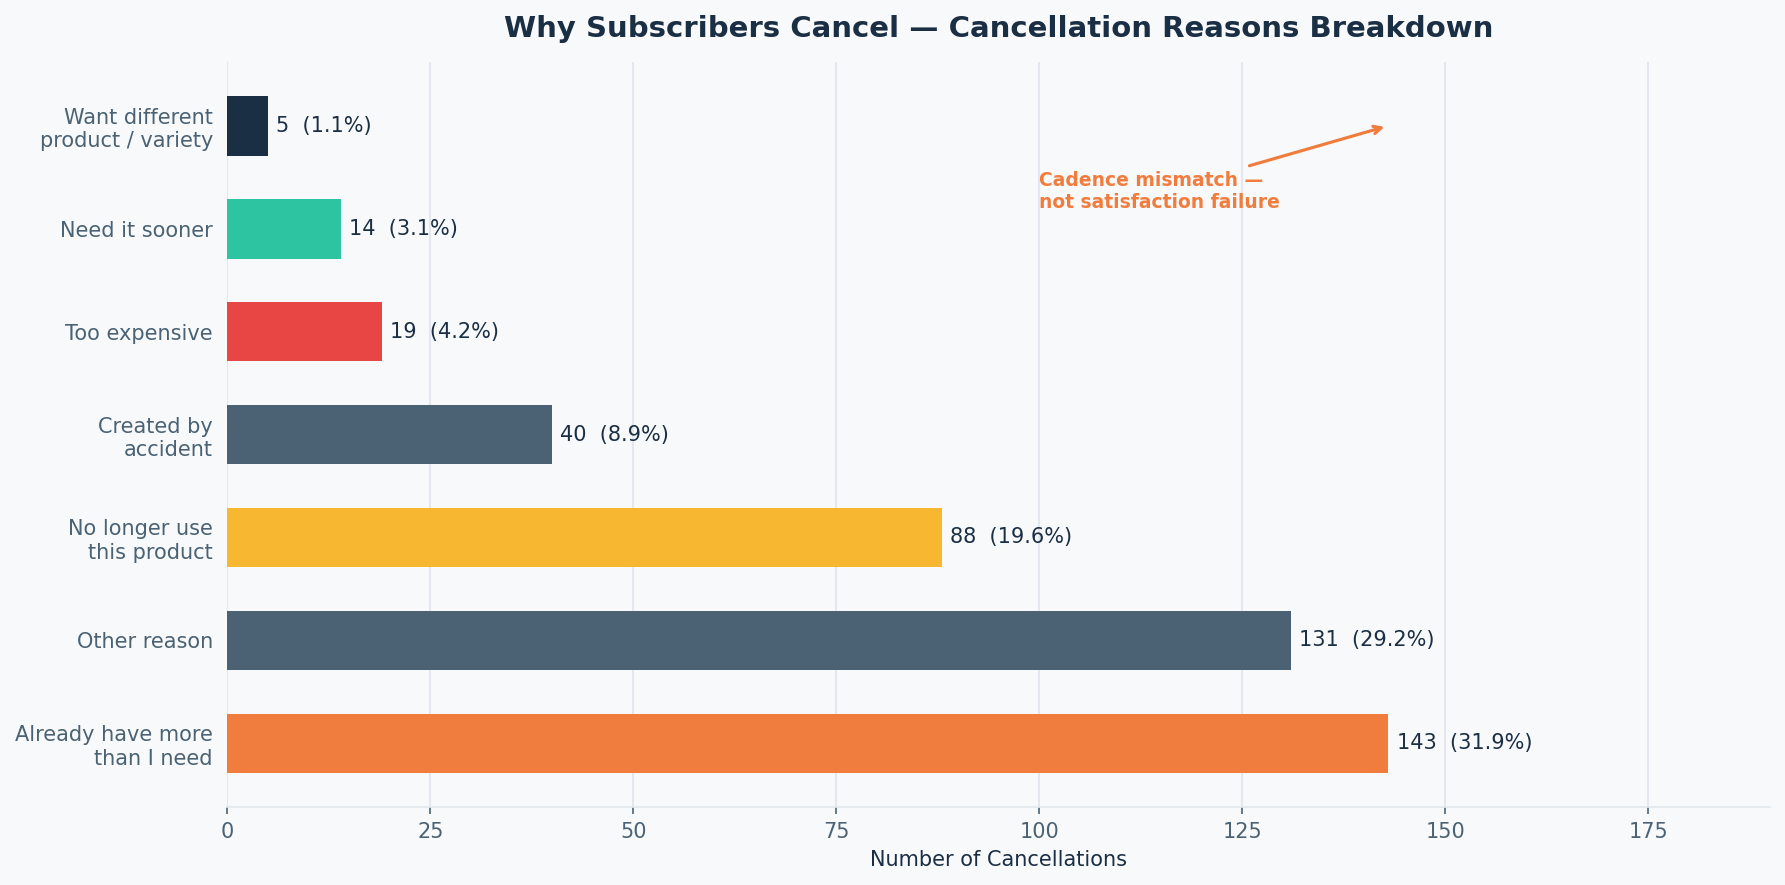

  Displayed inline: 04c_cancellation_reasons


In [5]:
# ── Chart 3: Cancellation reasons horizontal bar ─────────────────────────────
reasons = [
    "Already have more\nthan I need",
    "Other reason",
    "No longer use\nthis product",
    "Created by\naccident",
    "Too expensive",
    "Need it sooner",
    "Want different\nproduct / variety",
]
counts   = [143, 131, 88, 40, 19, 14, 5]
pcts     = [31.9, 29.2, 19.6, 8.9, 4.2, 3.1, 1.1]
theme_colors = [ORANGE, SLATE, GOLD, SLATE, RED, TEAL, NAVY]

fig, ax = plt.subplots(figsize=(12, 6))
y = np.arange(len(reasons))
bars = ax.barh(y, counts, color=theme_colors, height=0.58, zorder=3)
ax.set_yticks(y); ax.set_yticklabels(reasons, fontsize=10)
ax.set_title("Why Subscribers Cancel — Cancellation Reasons Breakdown")
ax.set_xlabel("Number of Cancellations", fontsize=10)
for i, (v, p) in enumerate(zip(counts, pcts)):
    ax.text(v+1, i, f"{v}  ({p:.1f}%)", va="center", fontsize=10, color=NAVY)

# Annotation for top reason
ax.annotate("Cadence mismatch —\nnot satisfaction failure",
            xy=(143, 6), xytext=(100, 5.2),
            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.5),
            fontsize=9, color=ORANGE, fontweight="bold")

ax.set_xlim(0, 190)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False); ax.tick_params(left=False)
fig.tight_layout()
save(fig, "04c_cancellation_reasons")



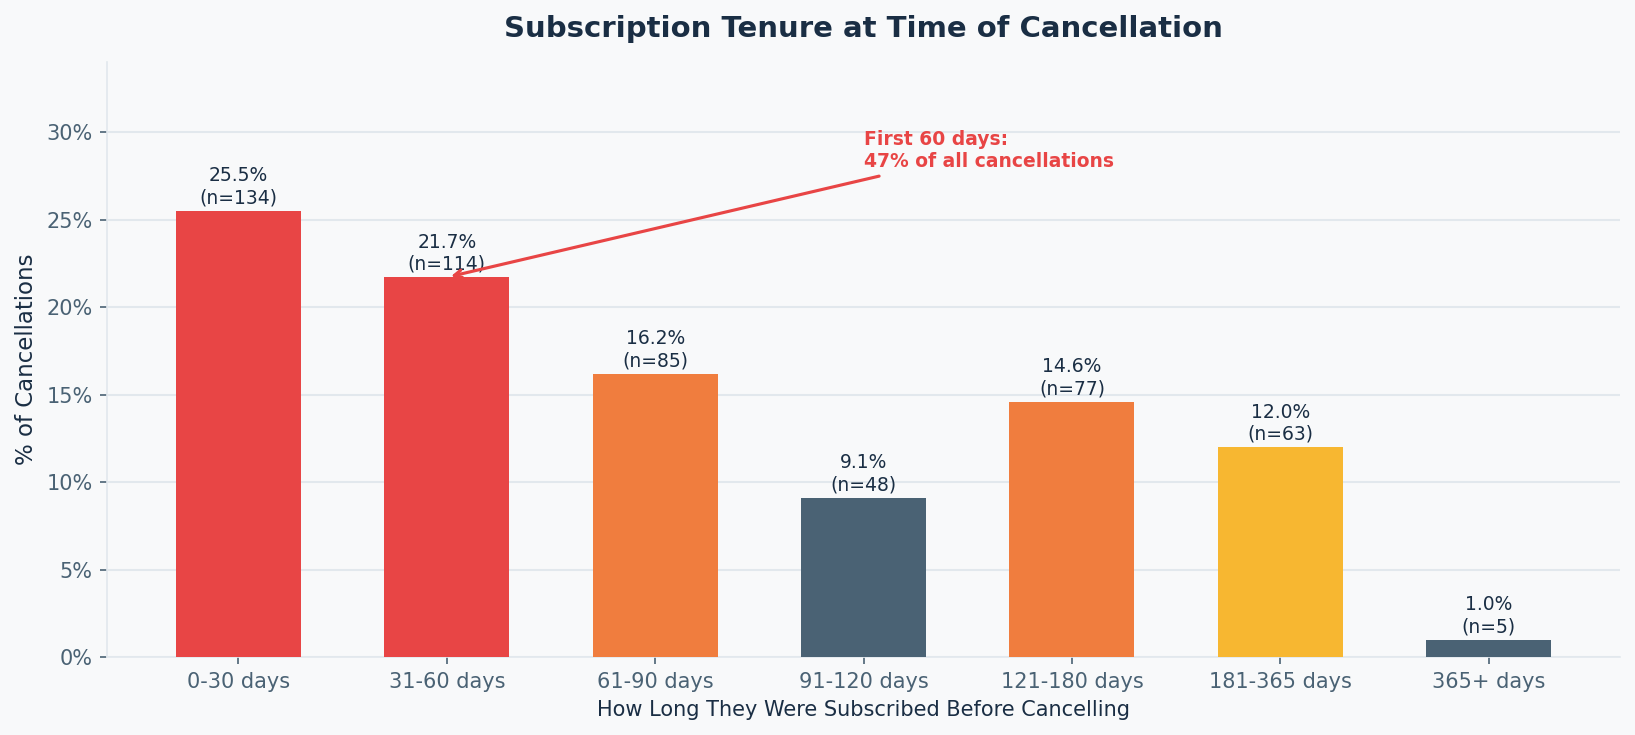

  Displayed inline: 04d_churn_tenure_distribution
Done – 04_subscription_churn


In [6]:
# ── Chart 4: Churn tenure distribution ────────────────────────────────────────
tenure_bins = ["0-30 days","31-60 days","61-90 days","91-120 days","121-180 days","181-365 days","365+ days"]
tenure_n    = [134, 114, 85, 48, 77, 63, 5]
tenure_pct  = [25.5, 21.7, 16.2, 9.1, 14.6, 12.0, 1.0]

fig, ax = plt.subplots(figsize=(11, 5))
colors = [RED if p > 20 else ORANGE if p > 13 else GOLD if p > 10 else SLATE for p in tenure_pct]
bars = ax.bar(tenure_bins, tenure_pct, color=colors, width=0.6, zorder=3)
ax.set_title("Subscription Tenure at Time of Cancellation")
ax.set_ylabel("% of Cancellations", fontsize=11)
ax.set_xlabel("How Long They Were Subscribed Before Cancelling", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
for bar, v, n in zip(bars, tenure_pct, tenure_n):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f"{v:.1f}%\n(n={n})", ha="center", va="bottom", fontsize=9, color=NAVY)
ax.set_ylim(0, 34)

cum_first3 = sum(tenure_pct[:3])
ax.annotate(f"First 60 days:\n{sum(tenure_pct[:2]):.0f}% of all cancellations",
            xy=(1, 21.7), xytext=(3, 28),
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.5),
            color=RED, fontsize=9, fontweight="bold")

fig.tight_layout()
save(fig, "04d_churn_tenure_distribution")

print("Done – 04_subscription_churn")
